# (15) another good fit: (32, 64.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')

cfg_vae['seq_len'] = 32
cfg_vae['tbptt_steps'] = -1
cfg_vae['n_iters_inner'] = 1

# cfg_vae['fit_prior'] = False
cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 64.0
cfg_tr['epochs'] = 300

cfg_tr['grad_clip'] = 500

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

vH16_t-32_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(64:0.1)_temp(0.05:0.5)_gr(500)_(2025_02_15,09:28)

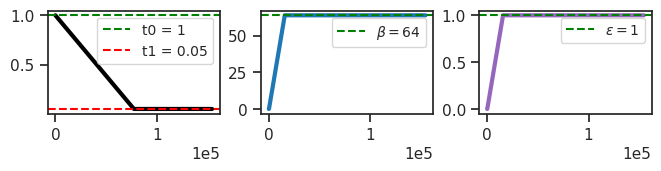

In [4]:
mod = IPVAE(ConfigPoisVAE(**cfg_vae))
self = tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [7]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr.exp()

(torch.Size([1, 512]), tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>))

In [8]:
# cm = f""
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 260.966088: 100%|████| 300/300 [3:23:10<00:00, 40.64s/it]


## take it from here

In [9]:
print(tr.model.layer.n_exp)

tensor([28, 32, 37, 43, 51, 61, 69, 77, 84, 88, 92, 94, 95, 96, 97, 97, 97, 97,
        97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97],
       device='cuda:1', dtype=torch.int32)

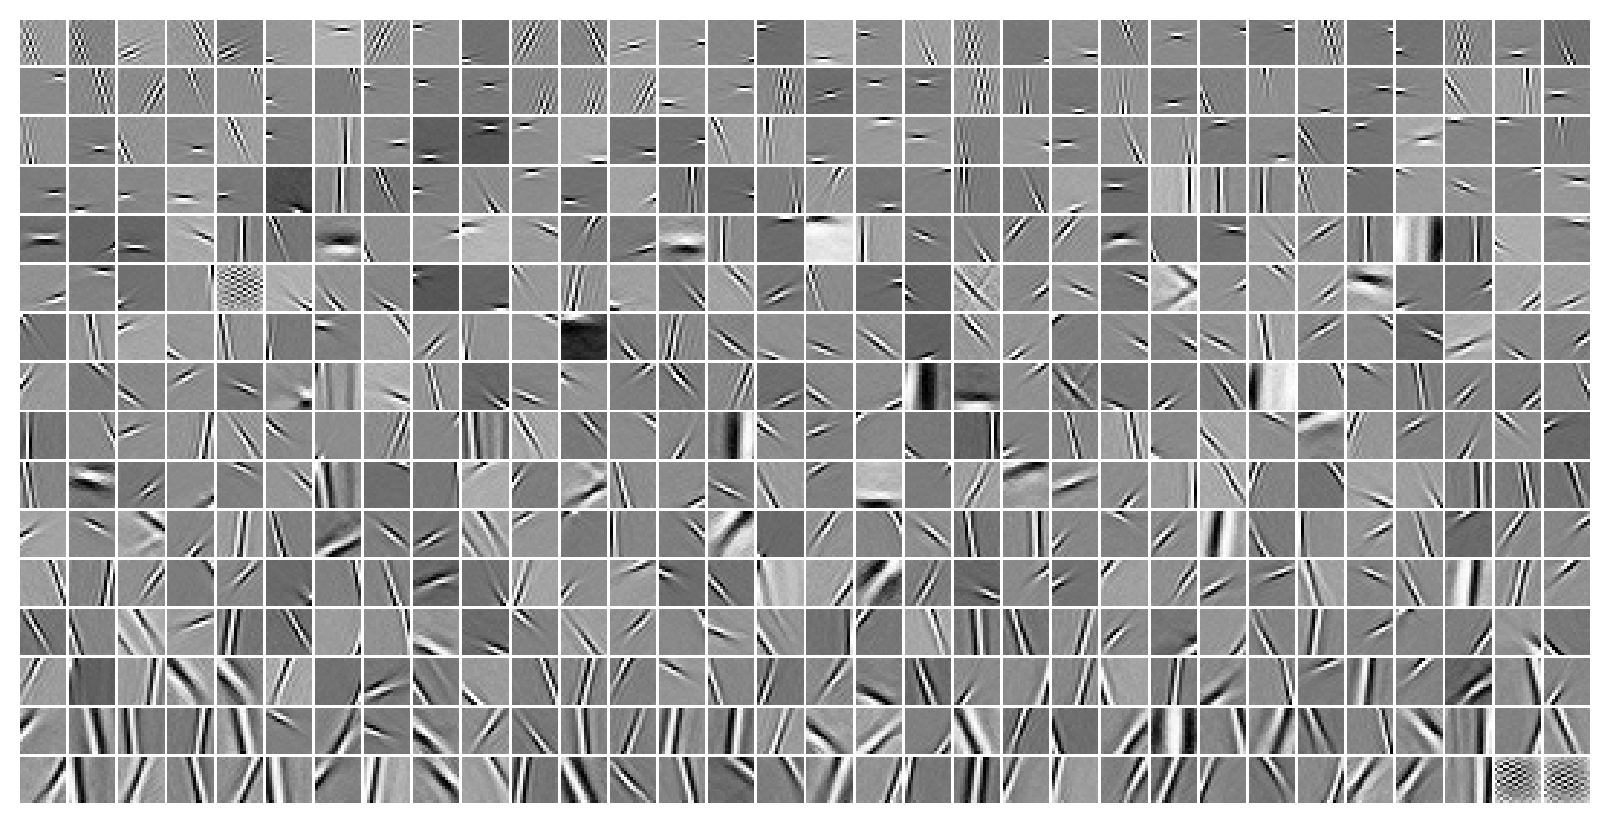

In [10]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

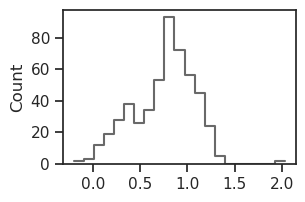

In [11]:
histplot(u0, color='dimgrey');

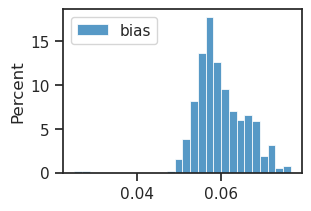

In [12]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

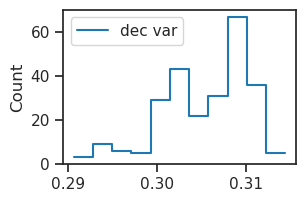

In [13]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

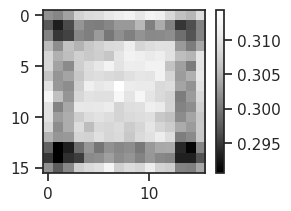

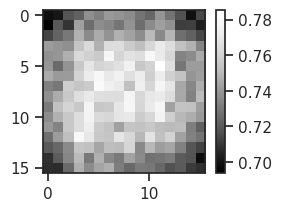

In [14]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 2/2 [00:42<00:00, 21.10s/it]


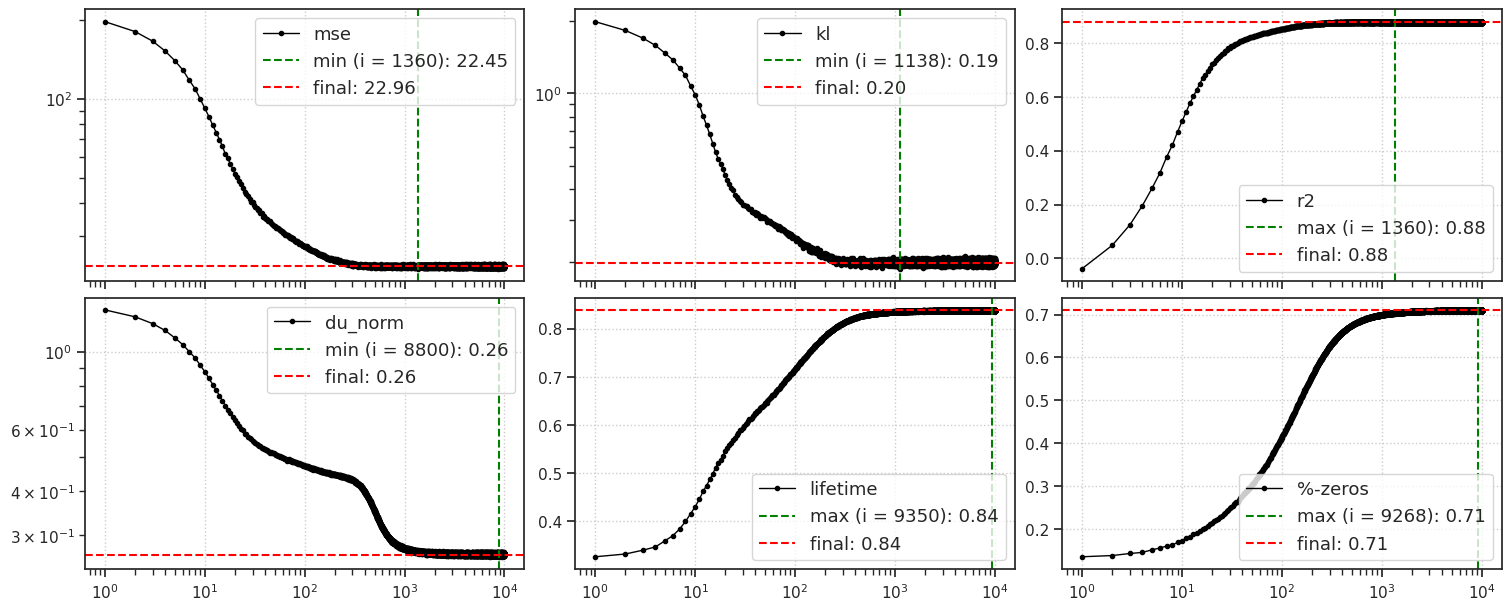

CPU times: user 50.5 s, sys: 2.96 s, total: 53.5 s
Wall time: 53.5 s


In [15]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [16]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

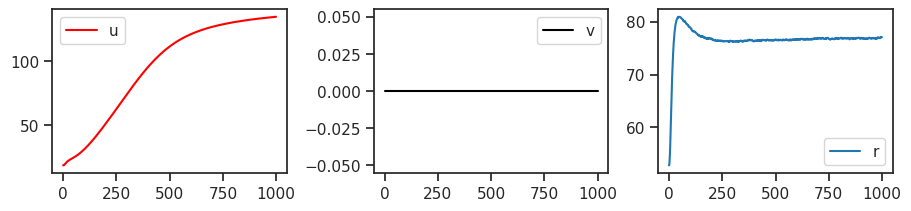

In [17]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

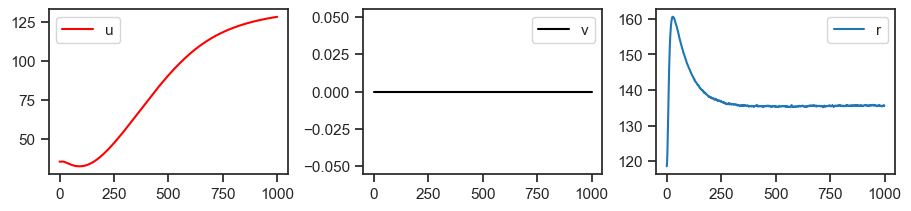

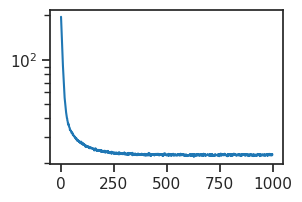

tensor([22.4723, 22.8794, 22.5076, 22.4879, 22.8188], device='cuda:1')

In [18]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log')
plt.show()

mse.mean(0)[-5:]

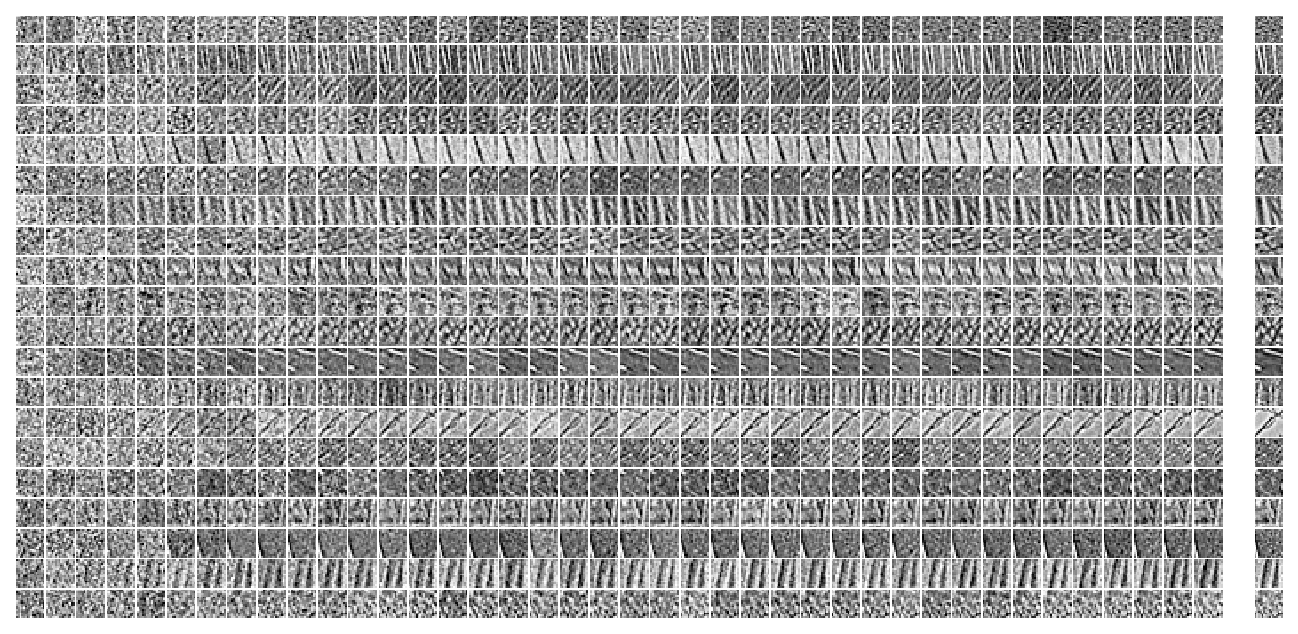

In [19]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

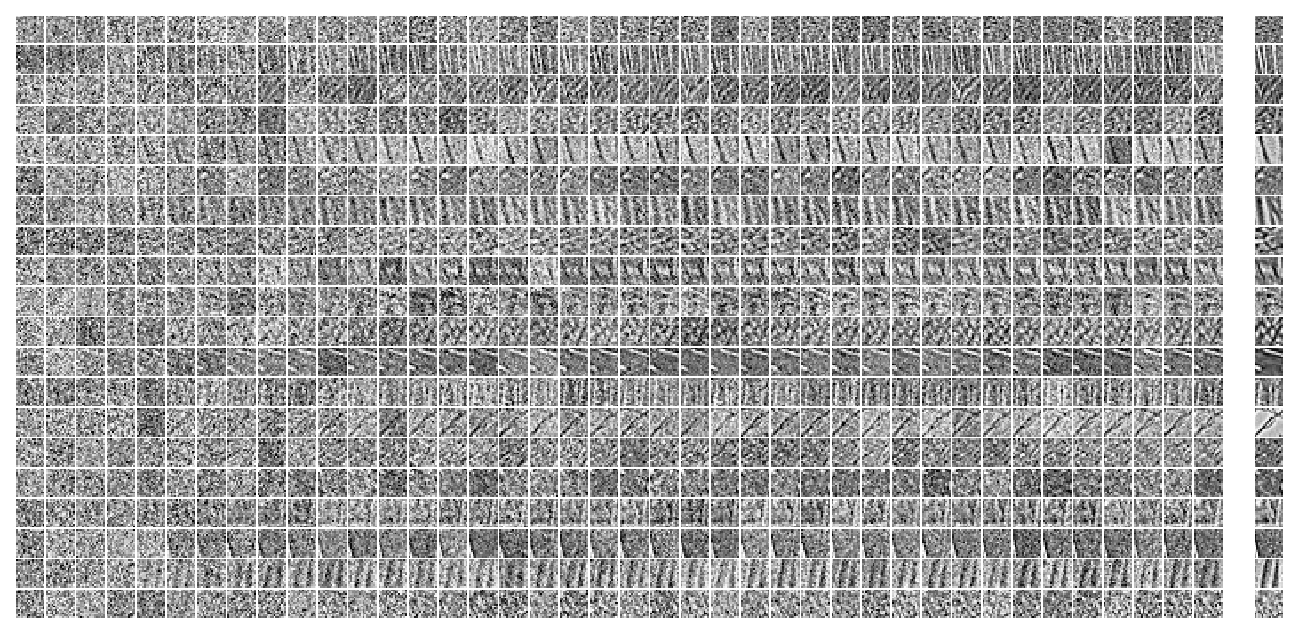

In [20]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

In [21]:
tr.time_keys

{'first': '0', 'last': '31', 'avg': 'avg'}

In [22]:
data, loss, etc = tr.forward('vld')
list(loss)

['kl', 'kl_diag', 'recon', 'nelbo']

In [23]:
from main.train import _prep

In [24]:
print(_prep(loss['kl'].mean(0)))

{
    '0': 1.9603463,
    '1': 1.7982134,
    '2': 1.669573,
    '3': 1.5589879,
    '4': 1.4584366,
    '5': 1.3587781,
    '6': 1.2613752,
    '7': 1.1601458,
    '8': 1.0621988,
    '9': 0.9686607,
    '10': 0.88146746,
    '11': 0.80252606,
    '12': 0.7329203,
    '13': 0.67182064,
    '14': 0.6195316,
    '15': 0.5734229,
    '16': 0.5358666,
    '17': 0.5025101,
    '18': 0.47539422,
    '19': 0.45204636,
    '20': 0.43231553,
    '21': 0.41662607,
    '22': 0.4027486,
    '23': 0.3906578,
    '24': 0.38051528,
    '25': 0.37180614,
    '26': 0.36268032,
    '27': 0.35765207,
    '28': 0.3519578,
    '29': 0.34679288,
    '30': 0.3427153,
    '31': 0.33831486,
    'avg': 0.7812188910320401
}

In [25]:
print(_prep(loss['recon'].mean(0)))

{
    '0': 403.64636,
    '1': 377.514,
    '2': 353.78757,
    '3': 331.55258,
    '4': 311.41934,
    '5': 292.96603,
    '6': 275.9508,
    '7': 260.37198,
    '8': 246.55199,
    '9': 234.19089,
    '10': 223.27089,
    '11': 213.57619,
    '12': 205.0501,
    '13': 197.54707,
    '14': 191.09337,
    '15': 185.29823,
    '16': 180.33469,
    '17': 175.80756,
    '18': 172.06024,
    '19': 168.53497,
    '20': 165.48811,
    '21': 162.87292,
    '22': 160.39267,
    '23': 158.25563,
    '24': 156.30708,
    '25': 154.60446,
    '26': 153.02069,
    '27': 151.5943,
    '28': 150.28584,
    '29': 149.10893,
    '30': 147.9699,
    '31': 147.02545,
    'avg': 214.29533910751343
}

In [26]:
print(_prep(loss['nelbo'].mean(0)))

{
    '0': 405.6079,
    '1': 379.3115,
    '2': 355.45828,
    '3': 333.11026,
    '4': 312.87628,
    '5': 294.32565,
    '6': 277.2109,
    '7': 261.53128,
    '8': 247.61491,
    '9': 235.15775,
    '10': 224.15198,
    '11': 214.37895,
    '12': 205.78261,
    '13': 198.21944,
    '14': 191.71288,
    '15': 185.87114,
    '16': 180.86993,
    '17': 176.3091,
    '18': 172.53508,
    '19': 168.98709,
    '20': 165.92021,
    '21': 163.2897,
    '22': 160.7966,
    '23': 158.64592,
    '24': 156.68793,
    '25': 154.97601,
    '26': 153.38406,
    '27': 151.95221,
    '28': 150.63792,
    '29': 149.4554,
    '30': 148.31302,
    '31': 147.36298,
    'avg': 215.07640266418457
}